# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh

rng = np.random.default_rng(0)

In [2]:
d = 40
k = 8
sigma = 0.1
n = 1500

W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)

## Low-Rank vs Diffuse Coefficient Changes

In [ ]:
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')

In [4]:
def sample(W):
    z = rng.normal(size=(n, k))
    eps = sigma * rng.normal(size=(n, d))
    return z @ W.T + eps

X_lr = sample(W0 + DeltaW_lr)
S_lr = (X_lr.T @ X_lr) / n

X_dense = sample(W0 + DeltaW_dense)
S_dense = (X_dense.T @ X_dense) / n

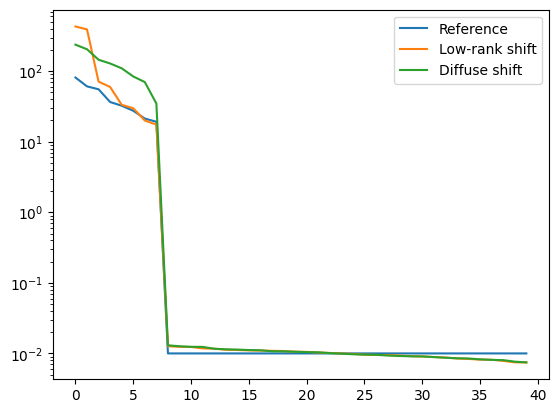

In [5]:
eig0 = eigvalsh(Sigma0)
eig_lr = eigvalsh(S_lr)
eig_dense = eigvalsh(S_dense)

plt.semilogy(eig0[::-1], label='Reference')
plt.semilogy(eig_lr[::-1], label='Low-rank shift')
plt.semilogy(eig_dense[::-1], label='Diffuse shift')
plt.legend()
plt.show()

# Step 1: Compute eigenvalues

In [6]:
sigma_eigvals = eigvalsh(Sigma0)
sigma_eigvals = np.sort(sigma_eigvals)[::-1]

print("The eignevalues for the reference covariance:")
print(sigma_eigvals)
print()

low_rank_eigenvals = eigvalsh(S_lr)
low_rank_eigenvals = np.sort(low_rank_eigenvals)[::-1]

print("The eignevalues for the low rank covariance:")
print(low_rank_eigenvals)
print()

diffuse_eigenvals = eigvalsh(S_dense)
diffuse_eigenvals = np.sort(diffuse_eigenvals)[::-1]

print("The eignevalues for the diffuse covariance:")
print(diffuse_eigenvals)
print()

The eignevalues for the reference covariance:
[8.12904989e+01 6.08975763e+01 5.53590309e+01 3.65448251e+01
 3.23855431e+01 2.74706222e+01 2.13097745e+01 1.91941980e+01
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02]

The eignevalues for the low rank covariance:
[4.30039174e+02 3.90421774e+02 7.10332740e+01 5.97109193e+01
 3.33562500e+01 2.98215196e+01 1.99861836e+01 1.74809418e+01
 1.26475331e-02 1.24047578e-02 1.23432727e-02 1.17905554e-02
 1.16660528e-02 1.12823255e-02 1.11877978e-02 1.10384656e-02
 1.09757327e-02 1.08913883e-02 1.08044227e-02 1.05888

# Step 2: Visualize the spectra

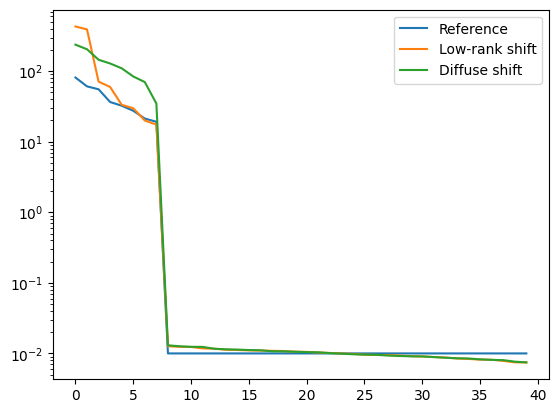

In [7]:
plt.semilogy(sigma_eigvals, label='Reference')
plt.semilogy(low_rank_eigenvals, label='Low-rank shift')
plt.semilogy(diffuse_eigenvals, label='Diffuse shift')
plt.legend()
plt.show()

# Step 3: Quantify "significant change"

Fixed Threshold: 10% relative difference.

In [8]:
low_rank_eigenvals_significant_change = []
diffuse_eigenvals_significant_change = []

for idx, sigma_eigval in enumerate(sigma_eigvals):
    s = sigma_eigval * 0.1
    if low_rank_eigenvals[idx] < sigma_eigval - s or low_rank_eigenvals[idx] > sigma_eigval + s:
        low_rank_eigenvals_significant_change.append(f"{low_rank_eigenvals[idx]} is a significant change from {sigma_eigval} at index {idx}")
print("The number of eigenvalues that were significantly changed for the low-rank shift: ", len(low_rank_eigenvals_significant_change))  
for v in low_rank_eigenvals_significant_change:
    print(v)

print()
for idx, sigma_eigval in enumerate(sigma_eigvals):
    s = sigma_eigval * 0.1
    if diffuse_eigenvals[idx] < sigma_eigval - s or diffuse_eigenvals[idx] > sigma_eigval + s:
        diffuse_eigenvals_significant_change.append(f"{diffuse_eigenvals[idx]} is a significant change from {sigma_eigval} at index {idx}")
print("The number of eigenvalues that were significantly changed for the diffuse shift: ", len(diffuse_eigenvals_significant_change))  
for v in diffuse_eigenvals_significant_change:
    print(v)


The number of eigenvalues that were significantly changed for the low-rank shift:  21
430.0391739857371 is a significant change from 81.29049888318666 at index 0
390.421773870575 is a significant change from 60.89757627090768 at index 1
71.0332740195606 is a significant change from 55.35903094087277 at index 2
59.710919348791386 is a significant change from 36.544825124762866 at index 3
0.012647533081005819 is a significant change from 0.010000000000023677 at index 8
0.012404757763279142 is a significant change from 0.010000000000019814 at index 9
0.012343272735940157 is a significant change from 0.010000000000017448 at index 10
0.01179055535862082 is a significant change from 0.010000000000015236 at index 11
0.011666052793997302 is a significant change from 0.010000000000013038 at index 12
0.01128232552638259 is a significant change from 0.010000000000010608 at index 13
0.01118779780048316 is a significant change from 0.010000000000010369 at index 14
0.011038465566433077 is a signific

# Step 4: Interpret the results

1. In the low-rank case, how many eigenvalues change substantially, and how does this number relate to the rank of the coefficient modification?

    In the low-rank case with a threshold of +-10% of the reference, there are only 4 eigenvalues that were substantially changed. This ignores the eigenvalues outside of the top 8 as those directions are just mostly noise. This lines up with rank_star = 2 as the number of significant eigenvalues changes are in the order of 2, but less than k.

2. In the diffuse case, why are many eigenvalues affected, even though the overall magnitude of the change is the same?

    Many eigenvalues were affected because there was no limitation on the rank for Delta W. This meant that the variance is free to substantially affect most directions.

3. How do these observations illustrate the idea that matrix rank limits the number of variance directions that can change?

    In the low_rank case, there were only 4 that were substantially changed which roughly is about the same as the rank of Delta W. It's not quite 2 because of the threshold I'm using but it's on a similar scale. In the dense case, the rank was not limited and the variance was spread out in many directions.
